# Bayesian Analysis of the Stroop Effect

## Research Question

Do incongruent Stroop trials produce longer reaction times than congruent trials?

## Hypothesis

Participants are expected to respond more slowly during incongruent trials than during congruent trials. Therefore, the posterior distribution of the condition effect is expected to indicate a positive increase in reaction time for incongruent trials.

## Variables

**Independent Variable**

- Experimental condition (Congruent vs. Incongruent)

**Dependent Variable**

- Reaction time (milliseconds)

## Bayesian Model

Reaction time will be modeled using Bayesian linear regression with condition as the predictor. Weakly informative Normal priors will be assigned to the regression coefficients, and a weakly informative Half-Normal prior will be assigned to the residual standard deviation.

## Data

This project uses a simulated Stroop dataset generated from predefined population parameters. Simulated data ensure full reproducibility while allowing evaluation of whether the Bayesian model successfully recovers the underlying parameters.

## Analysis Plan

1. Simulate reaction time data for congruent and incongruent conditions.
2. Perform basic data inspection and cleaning.
3. Fit a Bayesian linear regression model using PyMC.
4. Summarize posterior distributions using posterior means and 95% highest density intervals (HDIs).
5. Compute the posterior probability that the condition effect is greater than zero.
6. Evaluate model fit using posterior predictive checks.
7. Interpret the results in terms of cognitive processing and uncertainty.

## Expected Outcome

The posterior distribution is expected to support a positive Stroop interference effect, indicating that incongruent trials require longer response times than congruent trials. Bayesian inference will quantify both the estimated effect size and the uncertainty surrounding that estimate.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(1)

In [3]:
# Experimental design.

n_participants = 40

trials_per_condition = 30

conditions = [
    "Congruent",
    "Incongruent"
]

In [4]:
# Population parameters (milliseconds).

mean_congruent = 550

mean_incongruent = 650

within_subject_sd = 80

In [5]:
# Simulating the experiment.

rows = []

for participant in range(1, n_participants + 1):

    for condition in conditions:

        if condition == "Congruent":
            mean_rt = mean_congruent
        else:
            mean_rt = mean_incongruent

        reaction_times = rng.normal(
            loc=mean_rt,
            scale=within_subject_sd,
            size=trials_per_condition
        )

        for trial, rt in enumerate(reaction_times, start=1):

            rows.append({
                "participant": participant,
                "condition": condition,
                "trial": trial,
                "reaction_time": round(rt, 2)
            })

In [6]:
# Creating the dataset.

project_root = Path.cwd().parent

# Dataset directory

data_dir = project_root / "data"
data_dir.mkdir(parents=True, exist_ok=True)

# Create and save dataset

stroop = pd.DataFrame(rows)

output_path = data_dir / "bayesian-stroop-simulated.csv"
stroop.to_csv(output_path, index=False)

print(f"Saved dataset to: {output_path}")

Saved dataset to: /home/erfan/projects/research/computational-cognitive-science-training/data/bayesian-stroop-simulated.csv


In [7]:
# Displaying summary.

print(stroop.head())

print("\nObservations: ", len(stroop))

print("Participants: ", stroop["participant"].nunique())

print("Trials per participant: ", trials_per_condition * 2)

print("\n", stroop.groupby("condition")["reaction_time"].describe())

   participant  condition  trial  reaction_time
0            1  Congruent      1         577.65
1            1  Congruent      2         615.73
2            1  Congruent      3         576.43
3            1  Congruent      4         445.75
4            1  Congruent      5         622.43

Observations:  2400
Participants:  40
Trials per participant:  60

               count        mean        std     min       25%      50%  \
condition                                                               
Congruent    1200.0  552.062658  81.253566  317.59  495.7800  550.000   
Incongruent  1200.0  645.935483  79.475178  366.10  593.7875  647.735   

                  75%     max  
condition                      
Congruent    608.0975  850.13  
Incongruent  700.9975  898.00  


In [8]:
# Loading the dataset.

data_path = Path("../data") / "bayesian-stroop-simulated.csv"

stroop = pd.read_csv(data_path)

In [9]:
# Displaying the first observations.

print(stroop.head())

print("\nDataset shape:", stroop.shape)

   participant  condition  trial  reaction_time
0            1  Congruent      1         577.65
1            1  Congruent      2         615.73
2            1  Congruent      3         576.43
3            1  Congruent      4         445.75
4            1  Congruent      5         622.43

Dataset shape: (2400, 4)


In [10]:
# Dataset information.

print(stroop.info())

# Summary statistics.

print("\n", stroop.describe(include="all"))

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   participant    2400 non-null   int64  
 1   condition      2400 non-null   str    
 2   trial          2400 non-null   int64  
 3   reaction_time  2400 non-null   float64
dtypes: float64(1), int64(2), str(1)
memory usage: 75.1 KB
None

         participant  condition        trial  reaction_time
count   2400.000000       2400  2400.000000    2400.000000
unique          NaN          2          NaN            NaN
top             NaN  Congruent          NaN            NaN
freq            NaN       1200          NaN            NaN
mean      20.500000        NaN    15.500000     598.999071
std       11.545802        NaN     8.657245      93.061677
min        1.000000        NaN     1.000000     317.590000
25%       10.750000        NaN     8.000000     534.987500
50%       20.500000        NaN    15.500000 

In [11]:
# Checking for missing values.

print("Missing values:\n")

print(stroop.isna().sum())

Missing values:

participant      0
condition        0
trial            0
reaction_time    0
dtype: int64


In [12]:
# Checking duplicate observations.

duplicates = stroop.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [13]:
# Inspecting reaction times.

print(stroop["reaction_time"].describe())

count    2400.000000
mean      598.999071
std        93.061677
min       317.590000
25%       534.987500
50%       601.145000
75%       663.182500
max       898.000000
Name: reaction_time, dtype: float64


In [14]:
# Encoding the condition.

stroop["condition_code"] = (
    stroop["condition"] == "Incongruent"
).astype(int)

In [15]:
# Final Inspection

print(stroop.head())

print("\n", stroop.dtypes)

   participant  condition  trial  reaction_time  condition_code
0            1  Congruent      1         577.65               0
1            1  Congruent      2         615.73               0
2            1  Congruent      3         576.43               0
3            1  Congruent      4         445.75               0
4            1  Congruent      5         622.43               0

 participant         int64
condition             str
trial               int64
reaction_time     float64
condition_code      int64
dtype: object


In [16]:
# Building the Bayesian regression model.

with pm.Model() as stroop_model:

    # Predictor.

    condition = pm.Data(
        "condition",
        stroop["condition_code"]
    )

    # Priors.

    intercept = pm.Normal(
        "intercept",
        mu=600,
        sigma=150
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=100
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=100
    )

    # Expected reaction time.

    mu = intercept + slope * condition

    # Likelihood.

    reaction_time = pm.Normal(
        "reaction_time",
        mu=mu,
        sigma=sigma,
        observed=stroop["reaction_time"]
    )

    # Posterior sampling.

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope, sigma]
/home/erfan/projects/research/computational-cognitive-science-training/.venv/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


In [17]:
# Convergence Diagnostics

print(
    az.summary(
    trace,
    var_names=[
        "intercept",
        "slope",
        "sigma"
    ],
    ci_prob=0.95
    )
)

            mean    sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept  552.1  2.33      550      560     4297     4091  1.00     0.036   0.026
slope       93.8  3.28       87      100     4185     4353  1.00     0.051   0.036
sigma      80.42  1.16       78       83     5068     5003  1.00     0.016   0.011


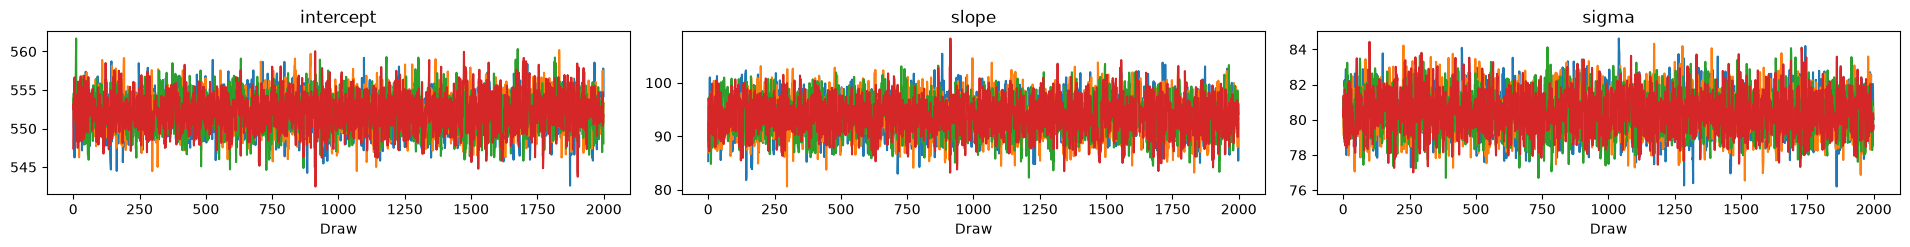

In [18]:
# Trace Plots

az.plot_trace(
    trace,
    var_names=[
        "intercept",
        "slope",
        "sigma"
    ]
)

plt.tight_layout()

plt.show()

In [19]:
# Posterior summary.

summary = az.summary(
    trace,
    var_names=[
        "intercept",
        "slope",
        "sigma"
    ],
    ci_prob=0.95
)

print(summary)

            mean    sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept  552.1  2.33      550      560     4297     4091  1.00     0.036   0.026
slope       93.8  3.28       87      100     4185     4353  1.00     0.051   0.036
sigma      80.42  1.16       78       83     5068     5003  1.00     0.016   0.011


In [20]:
# Probability that the Stroop effect is positive.

posterior = az.extract(
    trace,
    var_names=["slope"]
)

probability = (posterior.values > 0).mean()

print(f"P(Stroop effect > 0) = {probability:.3f}")

P(Stroop effect > 0) = 1.000


In [21]:
# Posterior predictive sampling.

with stroop_model:

    posterior_predictive = pm.sample_posterior_predictive(
        trace,
        random_seed=42
    )

print(posterior_predictive)

Sampling: [reaction_time]


Output()

<xarray.DataTree>
Group: /
├── Group: /posterior_predictive
│       Dimensions:              (chain: 4, draw: 2000, reaction_time_dim_0: 2400)
│       Coordinates:
│         * chain                (chain) int64 32B 0 1 2 3
│         * draw                 (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
│         * reaction_time_dim_0  (reaction_time_dim_0) int64 19kB 0 1 2 ... 2398 2399
│       Data variables:
│           reaction_time        (chain, draw, reaction_time_dim_0) float64 154MB 586...
│       Attributes:
│           created_at:                 2026-09-07T12:13:23.894782+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.1
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:              (reaction_time_dim_0: 2400)
│       Coordinates:
│   

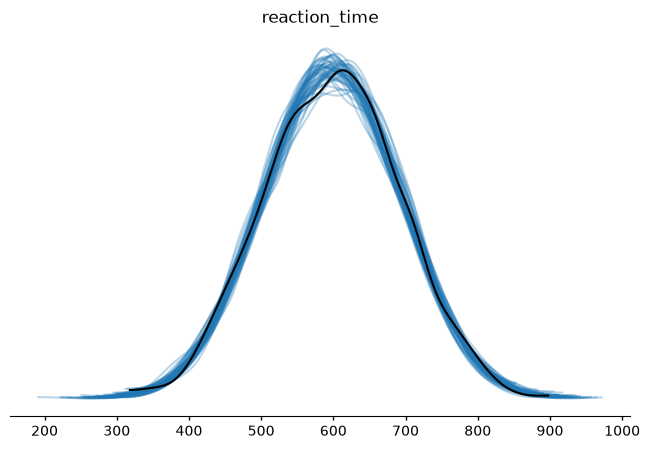

In [22]:
# Posterior predictive check.

azp.plot_ppc_dist(
    posterior_predictive,
    figure_kwargs={"figsize": (8, 5)}
)

plt.show()

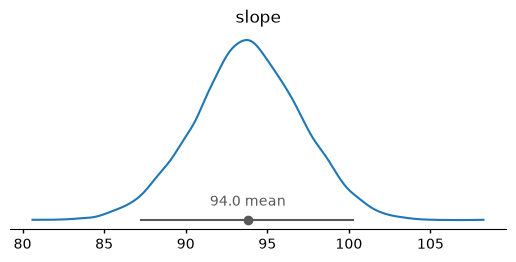

In [23]:
# Posterior distribution of the Stroop effect.

azp.plot_dist(
    trace,
    var_names=["slope"],
    ci_prob=0.95
)

plt.show()

<Figure size 800x500 with 0 Axes>

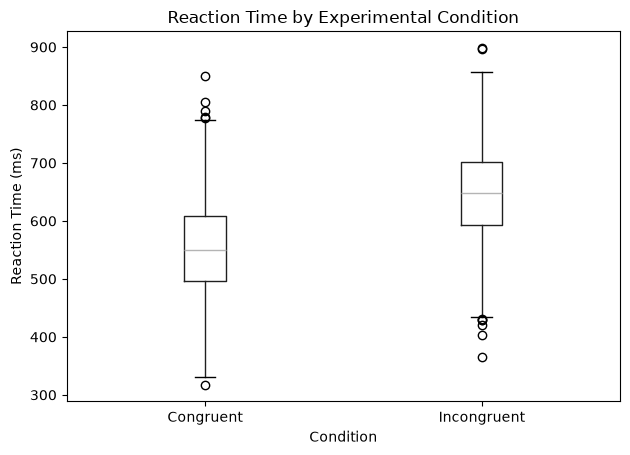

In [24]:
# Visualizing Reaction times by condition.

plt.figure(figsize=(8, 5))

stroop.boxplot(
    column="reaction_time",
    by="condition",
    grid=False
)

plt.title("Reaction Time by Experimental Condition")
plt.suptitle("")

plt.xlabel("Condition")
plt.ylabel("Reaction Time (ms)")

plt.tight_layout()

plt.show()

# Conclusion

This project demonstrated a complete Bayesian workflow, from study design and data simulation to posterior inference and model evaluation. The results illustrate how Bayesian methods estimate cognitive effects while explicitly quantifying uncertainty.